# Regression

## Objectives

*   Fit and evaluate a Regression model to predict SalePrice.


## Inputs

* outputs/datasets/cleaned/CleanedHousePricing.csv
* Instructions on which variables to use for data cleaning and feature engineering. They are found in their respective notebooks.

## Outputs

* Train set (features and target)
* Test set (features and target)
* ML pipeline to predict SalePrice
* labels map
* Feature Importance Plot



---

# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/rimanfarhood/development/pa/HeritageHousePrediction/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/rimanfarhood/development/pa/HeritageHousePrediction'

---

# Load Data

In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv("outputs/datasets/collection/cleaned/CleanedHousePricing.csv")
print(df.shape)
df.head(3)


(1460, 22)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500


# ML Pipeline: Regressor

## Create ML pipeline

In [5]:
# Feature Engineering
from feature_engine.encoding import OrdinalEncoder
from feature_engine import transformation as vt
from feature_engine.selection import SmartCorrelatedSelection

# Feat Scaling
from sklearn.preprocessing import StandardScaler

# Feat Selection
from sklearn.feature_selection import SelectFromModel

# ML algorithms
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
# from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor



def PipelineOptimization(model):
    pipeline_base = Pipeline([

        ("OrdinalCategoricalEncoder", OrdinalEncoder(encoding_method='arbitrary',
                                                 variables=['KitchenQual', 'GarageFinish', 'BsmtFinType1', 'BsmtExposure'])),

        ("YeoJohnsonTransformer", vt.YeoJohnsonTransformer(variables=['1stFlrSF', 'GrLivArea', 'LotArea', 'LotFrontage'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(variables=None, method="spearman", threshold=0.6, selection_method="variance")),

        ("feat_scaling", StandardScaler()),

        ("feat_selection",  SelectFromModel(model)),

        ("model", model),

    ])

    return pipeline_base


Custom Class for hyperparameter optimisation

In [6]:
from sklearn.model_selection import GridSearchCV


class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model = PipelineOptimization(self.models[key])

            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring)
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches

## Split Train Test Set

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['SalePrice'], axis=1),
    df['SalePrice'],
    test_size=0.2,
    random_state=0
)

print("* Train set:", X_train.shape, y_train.shape,
      "\n* Test set:",  X_test.shape, y_test.shape)


* Train set: (1168, 21) (1168,) 
* Test set: (292, 21) (292,)


## Grid Search CV - Sklearn

### Use default hyperparameters to find most suitable algorithm

In [8]:
models_quick_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    # "XGBRegressor": XGBRegressor(random_state=0),
}

params_quick_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    # "XGBRegressor": {},
}

### Do an extensive search on the most suitable model to find the best hyperparameter configuration.

In [9]:
quick_search = HyperparameterOptimizationSearch(models=models_quick_search, params=params_quick_search)
quick_search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Check Results 

In [10]:
grid_search_summary, grid_search_pipelines = quick_search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
2,RandomForestRegressor,0.659714,0.773029,0.822354,0.058605
3,ExtraTreesRegressor,0.640555,0.761573,0.805553,0.061321
5,GradientBoostingRegressor,0.569539,0.744436,0.834133,0.09523
0,LinearRegression,0.632463,0.726644,0.766316,0.049572
4,AdaBoostRegressor,0.477814,0.635974,0.749923,0.118218
1,DecisionTreeRegressor,0.440826,0.555414,0.650633,0.08687


Define model and parameters, for Extensive Search

In [11]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    'LinearRegression': LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
}

params_search = {
    "GradientBoostingRegressor": {
        'model__n_estimators': [7, 10, 20],
        'model__max_depth': [3,7,10],
        'model__min_samples_split': [5,7],

    },

    "ExtraTreesRegressor":{
        'model__n_estimators': [7],
        'model__max_depth': [3,7],
        'model__min_samples_split': [4,5,7],
    },
    
    'LinearRegression': {},
    
    "RandomForestRegressor": {
        'model__n_estimators': [7],
        'model__max_depth': [3,7,10],
        'model__min_samples_split': [4,5,7],
    },
}


Extensive GridSearch CV

In [12]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train, scoring = 'r2', n_jobs=-1, cv=6)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 6 folds for each of 6 candidates, totalling 36 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 6 folds for each of 18 candidates, totalling 108 fits

Running GridSearchCV for LinearRegression 

Fitting 6 folds for each of 1 candidates, totalling 6 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 6 folds for each of 9 candidates, totalling 54 fits


Check results

In [13]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__min_samples_split,model__n_estimators
3,ExtraTreesRegressor,0.570455,0.736858,0.827025,0.079703,7,4,7
14,GradientBoostingRegressor,0.64539,0.736708,0.787967,0.046047,7,5,20
17,GradientBoostingRegressor,0.642518,0.735744,0.782927,0.046332,7,7,20
4,ExtraTreesRegressor,0.613385,0.734482,0.833613,0.064337,7,5,7
5,ExtraTreesRegressor,0.598037,0.732691,0.836327,0.074353,7,7,7
23,GradientBoostingRegressor,0.654715,0.727087,0.788368,0.04719,10,7,20
24,LinearRegression,0.616022,0.713571,0.752002,0.045464,NaN,NaN,NaN
20,GradientBoostingRegressor,0.626551,0.710532,0.767134,0.047403,10,5,20
32,RandomForestRegressor,0.539997,0.700616,0.764857,0.075309,10,5,7
31,RandomForestRegressor,0.542521,0.699643,0.769972,0.07449,10,4,7


Check the best model

In [14]:
best_model = grid_search_summary.iloc[0,0]
best_model

'ExtraTreesRegressor'

Parameters for best model

In [15]:
best_parameters = grid_search_pipelines[best_model].best_params_
best_parameters

{'model__max_depth': 7,
 'model__min_samples_split': 4,
 'model__n_estimators': 7}

Define the best regressor, based on search

In [16]:
best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalCategoricalEncoder', ...), ('YeoJohnsonTransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'arbitrary'
,variables,"['KitchenQual', 'GarageFinish', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,variables,"['1stFlrSF', 'GrLivArea', ...]"
,variables,None


## Assess feature importance

* These are the 6 most important features in descending order. The model was trained on them: 
['TotalBsmtSF', 'GarageArea', 'YearBuilt', '2ndFlrSF', 'KitchenQual', 'GarageFinish']


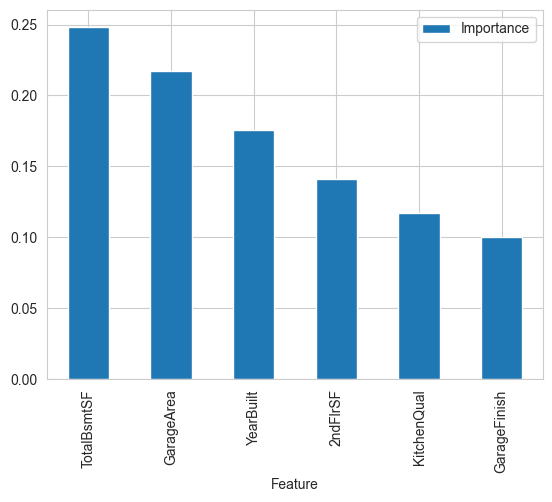

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# after data cleaning and feature engineering, the features may have changes
# how many data cleaning and feature engineering steps does your pipeline have?
data_cleaning_feat_eng_steps = 3
columns_after_data_cleaning_feat_eng = (Pipeline(best_regressor_pipeline.steps[:data_cleaning_feat_eng_steps])
                                        .transform(X_train)
                                        .columns)

best_features = columns_after_data_cleaning_feat_eng[best_regressor_pipeline['feat_selection'].get_support(
)].to_list()

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': columns_after_data_cleaning_feat_eng[best_regressor_pipeline['feat_selection'].get_support()],
    'Importance': best_regressor_pipeline['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()


## Evaluate on Train and Test Sets

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    prediction = pipeline.predict(X)
    print('R2 Score:', round(r2_score(y, prediction), 3))
    print('Mean Absolute Error:', round(mean_absolute_error(y, prediction), 3))
    print('Mean Squared Error:', round(mean_squared_error(y, prediction), 3))
    print('Root Mean Squared Error:', round(
        np.sqrt(mean_squared_error(y, prediction)), 3))
    print("\n")


def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    plt.show()


Evaluate Performance

Model Evaluation 

* Train Set
R2 Score: 0.873
Mean Absolute Error: 20031.24
Mean Squared Error: 783286950.019
Root Mean Squared Error: 27987.264


* Test Set
R2 Score: 0.797
Mean Absolute Error: 23545.93
Mean Squared Error: 1400662756.597
Root Mean Squared Error: 37425.429




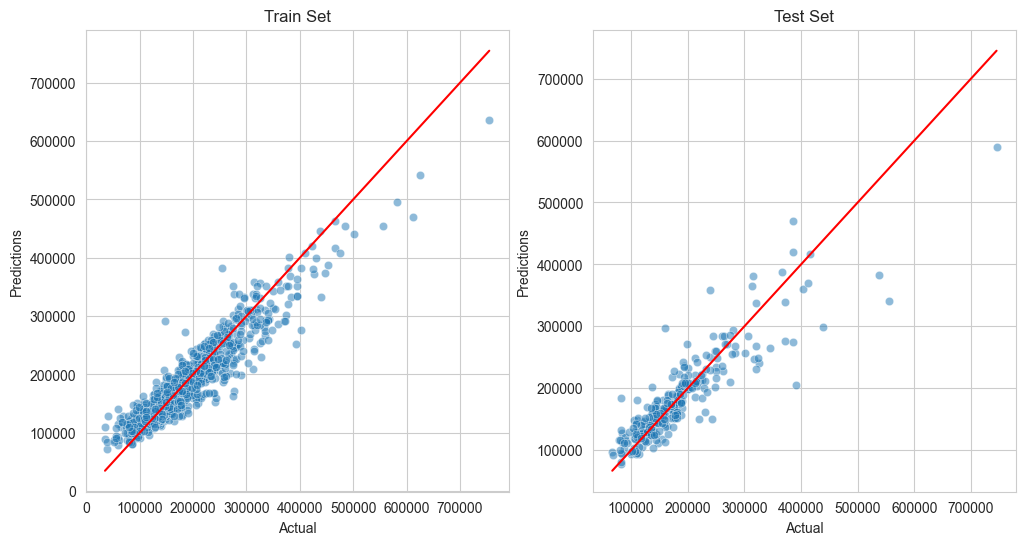

In [19]:
regression_performance(X_train, y_train, X_test, y_test, best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_regressor_pipeline)

## Evaluation

Now after having tried multiple models the results suggest there might be some overfitting based on the decrees in the test sets R2score, the lowest decrees reached is 7,4%. 

The results are not bad since they have reached the required threshold of an R2score of 75% on train and test.

Still there is room for improvement to get a more reliable model that perform on unseen data, so I'll try and make the pipeline a bit simpler for better results.

**Next step**

Adjust the pipeline and do the same process again.

----

### Rewrite Pipeline

Remove the numerical transformation step from pipeline

In [20]:
def PipelineOptimization(model):
    pipeline_base = Pipeline([

        ("OrdinalCategoricalEncoder", OrdinalEncoder(encoding_method='arbitrary',
                                                 variables=['KitchenQual', 'GarageFinish', 'BsmtFinType1', 'BsmtExposure'])),


        ("SmartCorrelatedSelection", SmartCorrelatedSelection(variables=None, method="spearman", threshold=0.6, selection_method="variance")),

        ("feat_scaling", StandardScaler()),

        ("feat_selection",  SelectFromModel(model)),

        ("model", model),

    ])

    return pipeline_base

### Use default hyperparameters to find most suitable algorithm

In [21]:
models_quick_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    # "XGBRegressor": XGBRegressor(random_state=0),
}

params_quick_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    # "XGBRegressor": {},
}

### Do an extensive search on the most suitable model to find the best hyperparameter configuration.

In [22]:
quick_search = HyperparameterOptimizationSearch(models=models_quick_search, params=params_quick_search)
quick_search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [23]:
grid_search_summary, grid_search_pipelines = quick_search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
2,RandomForestRegressor,0.679313,0.80015,0.85964,0.066829
3,ExtraTreesRegressor,0.653635,0.800031,0.870203,0.08051
0,LinearRegression,0.646208,0.764991,0.819271,0.062684
5,GradientBoostingRegressor,0.61241,0.762478,0.850056,0.10032
4,AdaBoostRegressor,0.602377,0.72915,0.798809,0.0715
1,DecisionTreeRegressor,0.374561,0.597513,0.730248,0.11992


In [24]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
}

params_search = {
    "ExtraTreesRegressor":{
        'model__n_estimators': [7],
        'model__max_depth': [8],
        'model__min_samples_split': [4],
    },
}


In [25]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train, scoring = 'r2', n_jobs=-1, cv=6)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 6 folds for each of 1 candidates, totalling 6 fits


In [26]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__min_samples_split,model__n_estimators
0,ExtraTreesRegressor,0.60967,0.798045,0.854337,0.087025,8,4,7


Check for best model and parameters

In [27]:
best_model = grid_search_summary.iloc[0,0]
best_model

'ExtraTreesRegressor'

In [28]:
best_parameters = grid_search_pipelines[best_model].best_params_
best_parameters

{'model__max_depth': 8,
 'model__min_samples_split': 4,
 'model__n_estimators': 7}

Check best pipeline

In [29]:
best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalCategoricalEncoder', ...), ('SmartCorrelatedSelection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'arbitrary'
,variables,"['KitchenQual', 'GarageFinish', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,variables,None
,method,'spearman'


### Assess feature importance

* These are the 5 most important features in descending order. The model was trained on them: 
['GrLivArea', 'TotalBsmtSF', 'KitchenQual', 'YearBuilt', 'GarageArea']


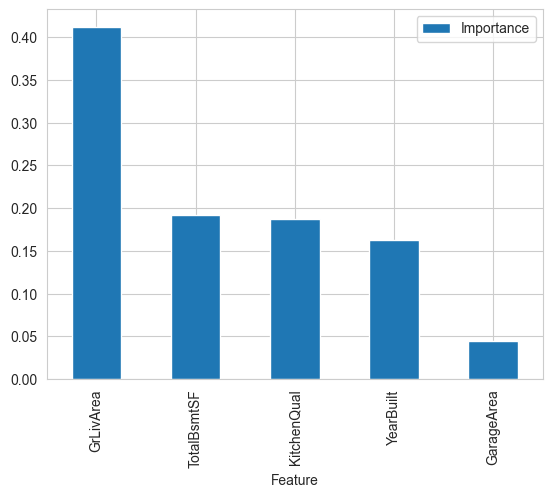

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# after data cleaning and feature engineering, the features may have changes
# how many data cleaning and feature engineering steps does your pipeline have?
data_cleaning_feat_eng_steps = 2
columns_after_data_cleaning_feat_eng = (Pipeline(best_regressor_pipeline.steps[:data_cleaning_feat_eng_steps])
                                        .transform(X_train)
                                        .columns)

best_features = columns_after_data_cleaning_feat_eng[best_regressor_pipeline['feat_selection'].get_support(
)].to_list()

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': columns_after_data_cleaning_feat_eng[best_regressor_pipeline['feat_selection'].get_support()],
    'Importance': best_regressor_pipeline['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()


## Evaluate on Train and Test Sets

Model Evaluation 

* Train Set
R2 Score: 0.918
Mean Absolute Error: 16307.308
Mean Squared Error: 503333315.026
Root Mean Squared Error: 22435.091


* Test Set
R2 Score: 0.844
Mean Absolute Error: 21389.809
Mean Squared Error: 1075513086.464
Root Mean Squared Error: 32795.016




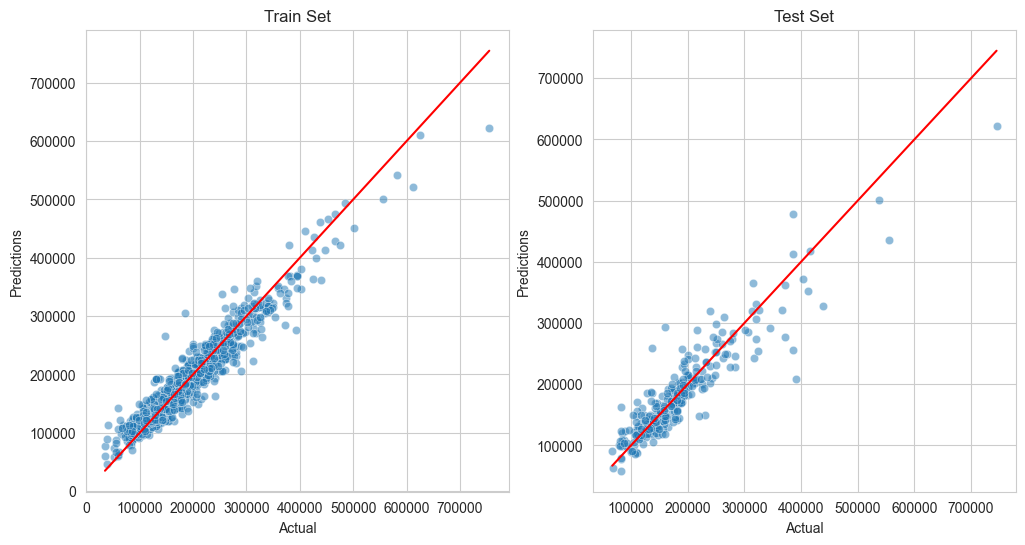

In [31]:
regression_performance(X_train, y_train, X_test, y_test, best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_regressor_pipeline)

### Evaluation

The Results are much better now with a higher score on the test set and a lower decrees of 4,1% on the test set R2score. 

**Next step**

Try modelling with PCA 

---

## ML with PCA

Let's explore potential values for PCA n_components.

In [32]:
pipeline = PipelineOptimization(model=ExtraTreesRegressor())
pipeline_pca = Pipeline(pipeline.steps[:2])
df_pca = pipeline_pca.fit_transform(df.drop(['SalePrice'], axis=1))

print(df_pca.shape,'\n', type(df_pca))

(1460, 16) 
 <class 'pandas.core.frame.DataFrame'>


Apply PCA separately to the scaled data

* The 14 components explain 100.0% of the data 



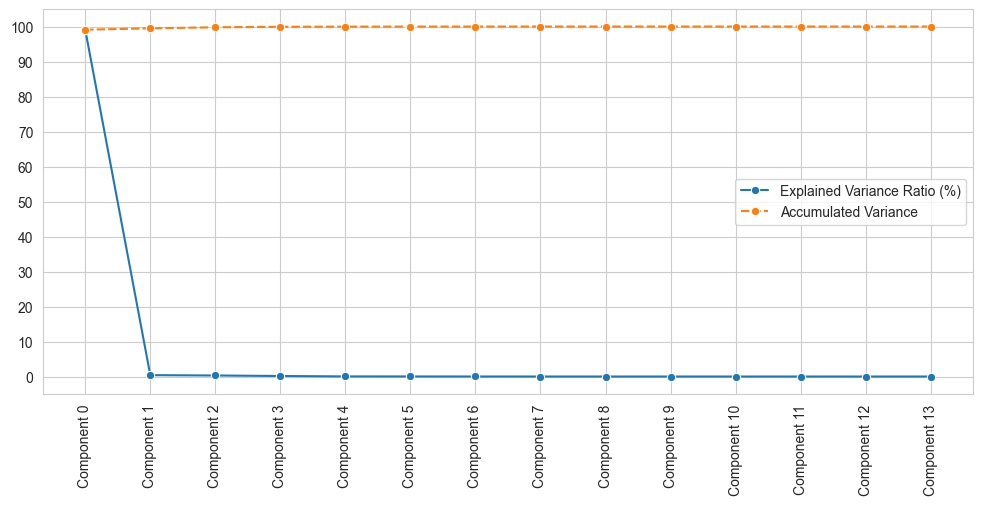

In [33]:
import numpy as np
from sklearn.decomposition import PCA

n_components = 14


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)
    x_PCA = pca.transform(df_pca)  # array with transformed PCA

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = dfExplVarRatio['Explained Variance Ratio (%)'].cumsum(
    )

    PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum(
    )

    print(
        f"* The {n_components} components explain {round(PercentageOfDataExplained,2)}% of the data \n")
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=dfExplVarRatio,  marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)


* The 7 components explain 99.99% of the data 



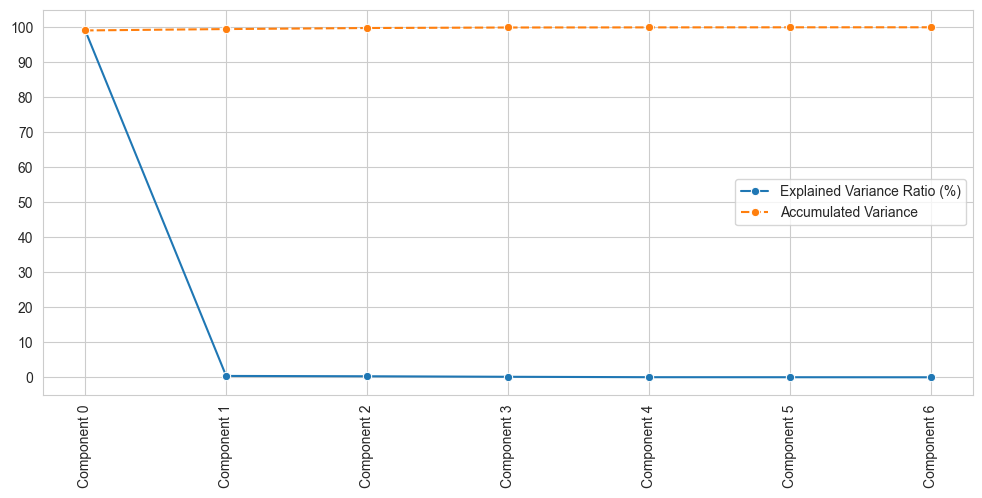

In [34]:
n_components = 7
pca_components_analysis(df_pca=df_pca, n_components=n_components)

## Rewrite ML Pipeline for Modelling

In [35]:
# PCA
from sklearn.decomposition import PCA


def PipelineOptimization(model):
    pipeline_base = Pipeline([

        ("OrdinalCategoricalEncoder", OrdinalEncoder(encoding_method='arbitrary',
                                                     variables=['KitchenQual', 'GarageFinish', 'BsmtFinType1', 'BsmtExposure'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(variables=None,
         method="spearman", threshold=0.6, selection_method="variance")),

        ("feat_scaling", StandardScaler()),

        # PCA replace Feature Selection
        ("PCA", PCA(n_components=7, random_state=0)),

        ("model", model),

    ])

    return pipeline_base


## Grid Search CV – Sklearn

In [36]:
print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

* Train set: (1168, 21) (1168,) 
* Test set: (292, 21) (292,)


### Use standard hyperparameters to find the most suitable model.

In [37]:
models_quick_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    # "XGBRegressor": XGBRegressor(random_state=0),
}

params_quick_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    # "XGBRegressor": {},
}


Do a quick optimisation search 

In [38]:
quick_search = HyperparameterOptimizationSearch(models=models_quick_search, params=params_quick_search)
quick_search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Check results

In [39]:
grid_search_summary, grid_search_pipelines = quick_search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
2,RandomForestRegressor,0.694261,0.760108,0.829913,0.043745
5,GradientBoostingRegressor,0.612615,0.746264,0.825042,0.07244
3,ExtraTreesRegressor,0.59512,0.740561,0.84236,0.081016
0,LinearRegression,0.601713,0.720582,0.785602,0.064281
4,AdaBoostRegressor,0.611736,0.706861,0.739061,0.047935
1,DecisionTreeRegressor,0.418817,0.546569,0.662072,0.087869


### Do an extensive search on the most suitable model to find the best hyperparameter configuration.

Define model and parameters for extensive search

In [40]:
pca_models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    
}




pca_params_search = {
    "ExtraTreesRegressor":{
        'model__n_estimators': [6],
        'model__max_depth': [8],
        'model__min_samples_split': [4],
    }
}


Extensive GridSearch CV

In [41]:
search = HyperparameterOptimizationSearch(models=pca_models_search, params=pca_params_search)
search.fit(X_train, y_train, scoring = 'r2', n_jobs=-1, cv=5)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Check results

In [42]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__min_samples_split,model__n_estimators
0,ExtraTreesRegressor,0.600829,0.725475,0.811126,0.072359,8,4,6


Check the best model

In [43]:
best_model_pca = grid_search_summary.iloc[0,0]
best_model_pca

'ExtraTreesRegressor'

Parameters for best model

In [44]:
best_parameters_pca = grid_search_pipelines[best_model_pca].best_params_
best_parameters_pca

{'model__max_depth': 8,
 'model__min_samples_split': 4,
 'model__n_estimators': 6}

Define the best regressor

In [45]:
best_pca_regressor_pipeline = grid_search_pipelines[best_model_pca].best_estimator_
best_pca_regressor_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalCategoricalEncoder', ...), ('SmartCorrelatedSelection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'arbitrary'
,variables,"['KitchenQual', 'GarageFinish', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,variables,None
,method,'spearman'


## Evaluate Regressor on Train and Tests Sets

Model Evaluation 

* Train Set
R2 Score: 0.882
Mean Absolute Error: 19054.017
Mean Squared Error: 727440687.913
Root Mean Squared Error: 26971.108


* Test Set
R2 Score: 0.717
Mean Absolute Error: 26302.393
Mean Squared Error: 1954208222.228
Root Mean Squared Error: 44206.427




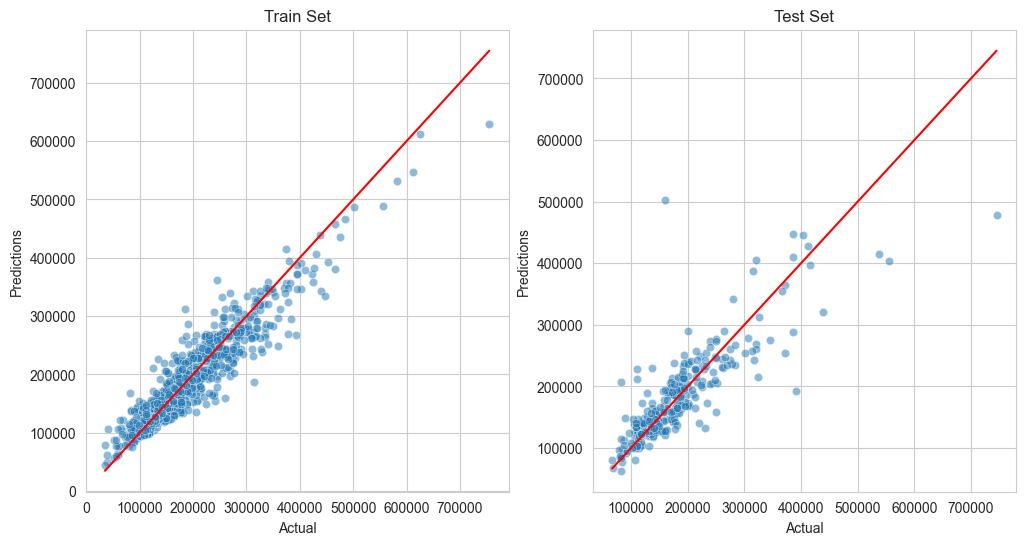

In [46]:
regression_performance(X_train, y_train, X_test, y_test,best_pca_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test,
                            best_pca_regressor_pipeline)

# Which pipeline to choose?

We fitted 3 pipelines:
* Regression with feature engineering
* Regression without feature engineering
* Regression with PCA


Best:
Regression without feature engineering
- Train: 0.91 R2 Score
- Test: 0.84 R2 Score


All three regressor pipelines did reach above the expected performance threshold (0.75 R2 score) for the train and test set.
* The regression pipeline without feature engineering and PCA performed better with a higher R2 score and less decrees on the test sets R2 Score

# Refit pipeline with best features

Since none of the best features need feature engineering, I've removed all engineering steps from the pipeline.

In [47]:
def PipelineOptimization(model):
    pipeline_base = Pipeline([
                 ("OrdinalCategoricalEncoder", OrdinalEncoder(encoding_method='arbitrary',
                                                                variables=['KitchenQual'])),
               ("feat_scaling", StandardScaler()),
               ("model", model),

    ])

    return pipeline_base

### Split Train and Test sets with only the best features

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(
                                    df.drop(['SalePrice'],axis=1),
                                    df['SalePrice'],
                                    test_size = 0.2,
                                    random_state = 0,
                                    )

print("* Train set:", X_train.shape, y_train.shape,
      "\n* Test set:",  X_test.shape, y_test.shape)


* Train set: (1168, 21) (1168,) 
* Test set: (292, 21) (292,)


Subset Best Features

In [49]:
best_features

['GarageArea', 'GrLivArea', 'KitchenQual', 'TotalBsmtSF', 'YearBuilt']

In [50]:
X_train = X_train.filter(best_features)
X_test = X_test.filter(best_features)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)
X_train.head(3)

* Train set: (1168, 5) (1168,) 
* Test set: (292, 5) (292,)


,GarageArea,GrLivArea,KitchenQual,TotalBsmtSF,YearBuilt
618,774,1828,Gd,1822,2007
870,308,894,TA,894,1962
92,432,964,TA,876,1921


## Grid Search CV - Sklearn

In [51]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
}

params_search = {
    "ExtraTreesRegressor":{
        'model__n_estimators': [7],
        'model__max_depth': [8],
        'model__min_samples_split': [4],
    },
}

params_search

{'ExtraTreesRegressor': {'model__n_estimators': [7],
  'model__max_depth': [8],
  'model__min_samples_split': [4]}}

In [52]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train, scoring = 'r2', n_jobs=-1, cv=6)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 6 folds for each of 1 candidates, totalling 6 fits


In [53]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__min_samples_split,model__n_estimators
0,ExtraTreesRegressor,0.581559,0.791742,0.848898,0.09625,8,4,7


In [54]:
best_model = grid_search_summary.iloc[0,0]
best_model

'ExtraTreesRegressor'

In [55]:
best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalCategoricalEncoder', ...), ('feat_scaling', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'arbitrary'
,variables,['KitchenQual']
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


Model Evaluation 

* Train Set
R2 Score: 0.918
Mean Absolute Error: 16307.308
Mean Squared Error: 503333315.026
Root Mean Squared Error: 22435.091


* Test Set
R2 Score: 0.844
Mean Absolute Error: 21389.809
Mean Squared Error: 1075513086.464
Root Mean Squared Error: 32795.016




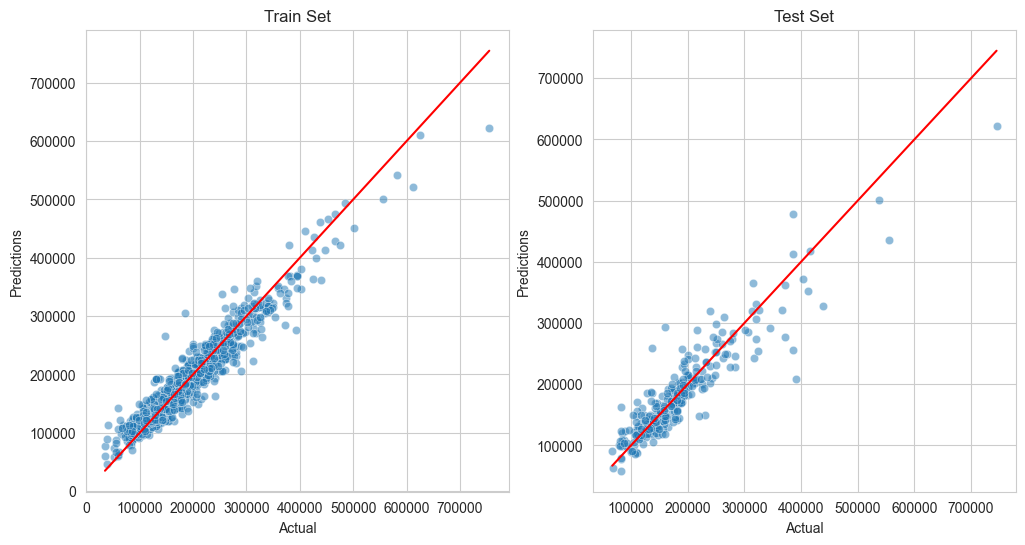

In [56]:
regression_performance(X_train, y_train, X_test, y_test, best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_regressor_pipeline)

# Push files to the repo

We will generate the following files

* Train set
* Test set
* Modeling pipeline
* features importance plot

In [57]:
import joblib
import os

version = 'v1'
file_path = f'outputs/ml_pipeline/predict_SalePrice/{version}'

try:
  os.makedirs(name=file_path)
except Exception as e:
  print(e)

[Errno 17] File exists: 'outputs/ml_pipeline/predict_SalePrice/v1'


## Train Set: features and target

In [58]:
X_train.head()

,GarageArea,GrLivArea,KitchenQual,TotalBsmtSF,YearBuilt
618,774,1828,Gd,1822,2007
870,308,894,TA,894,1962
92,432,964,TA,876,1921
817,857,1689,Gd,1568,2002
302,843,1541,Gd,1541,2001


In [59]:
X_train.to_csv(f"{file_path}/X_train.csv", index=False)

In [60]:
y_train

618     314813
870     109500
92      163500
817     271000
302     205000
         ...  
763     337000
835     128000
1216    112000
559     234000
684     221000
Name: SalePrice, Length: 1168, dtype: int64

In [61]:
y_train.to_csv(f"{file_path}/y_train.csv", index=False)

## Test Set: features and target

In [62]:
X_test.head()

,GarageArea,GrLivArea,KitchenQual,TotalBsmtSF,YearBuilt
529,484,2515,TA,2035,1957
491,240,1578,Fa,806,1941
459,352,1203,Gd,709,1950
279,505,2022,TA,1160,1977
655,264,1092,TA,525,1971


In [63]:
X_test.to_csv(f"{file_path}/X_test.csv", index=False)

In [64]:
y_test

529     200624
491     133000
459     110000
279     192000
655      88000
         ...  
326     324000
440     555000
1387    136000
1323     82500
61      101000
Name: SalePrice, Length: 292, dtype: int64

In [65]:
y_test.to_csv(f"{file_path}/y_test.csv", index=False)

## Modelling pipeline

ML pipeline for predicting SalePrice

In [66]:
pipeline = best_regressor_pipeline


In [67]:
joblib.dump(value=pipeline, filename=f"{file_path}/pipeline.pkl")

['outputs/ml_pipeline/predict_SalePrice/v1/pipeline.pkl']

## Feature importance plot

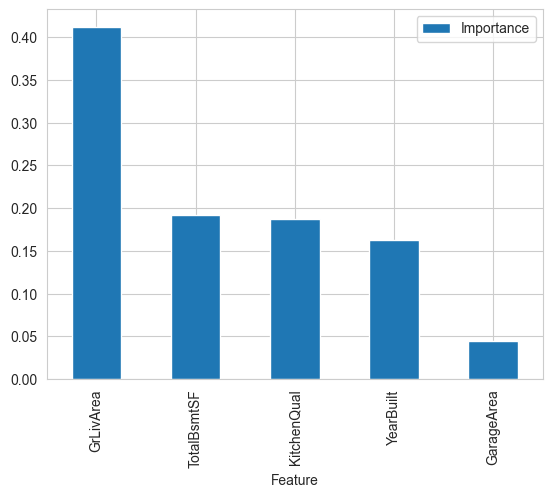

In [68]:
df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()

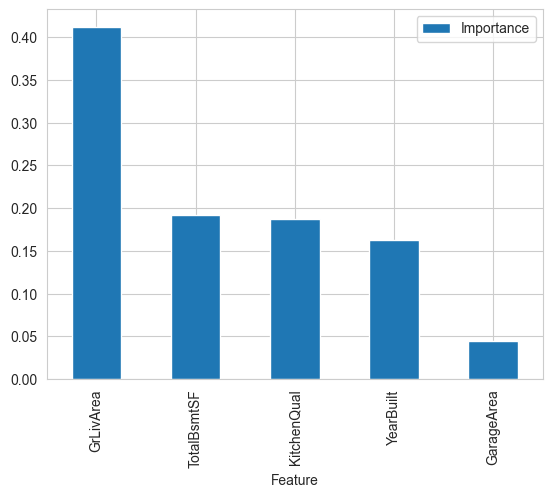

In [69]:
df_feature_importance.plot(kind='bar',x='Feature',y='Importance')
plt.savefig(f'{file_path}/features_importance.png', bbox_inches='tight')

---